In [1]:
# ============================================================================
# BLOCK 4: SENTIMENT ANALYSIS - POLISH
# Input: 03_filtered_data_pl.pkl
# Output: 04_sentiment_data_pl.pkl
# Runtime: ~25-35 minutes on CPU
# ============================================================================
%run 00_setup_and_config.ipynb

c:\Users\andre\OneDrive\Desktop\2_Disertatie_RIPEMC_D.Flanja\Quantitative_Python\election_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded successfully
✓ PyTorch device: CPU
✓ Timestamp: 2026-05-29 04:10:48
✓ Directory structure verified
✓ Base directory: c:\Users\andre\OneDrive\Desktop\2_Disertatie_RIPEMC_D.Flanja\Quantitative_Python\YT_Analysis
✓ Model configuration loaded
  - Polish sentiment: eevvgg/bert-polish-sentiment-politics
  - Romanian sentiment: readerbench/ro-sentiment
  - Embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  - BERTopic topics: 8
  - Batch size: 8
✓ Checkpoint utility functions loaded
✓ Text cleaning functions loaded
✓ Romanian stopwords: 385 words
✓ Polish stopwords: 511 words
✓ Visualization utility functions loaded
✓ Sentiment prediction function loaded
✓ SETUP AND CONFIGURATION COMPLETE

Ready for analysis. Next steps:
  1. Run Polish pipeline: 01_data_loading_pl.ipynb → 06_engagement_metrics_pl.ipynb
  2. Run Romanian pipeline: 01_data_loading_ro.ipynb → 06_engagement_metrics_ro.ipynb
  3. (Optional) Run comparative analysis: 08_comparative_ana

In [2]:
# CELL 1: Load previous checkpoint
print('='*70)
print('BLOCK 4: SENTIMENT ANALYSIS - POLISH')
print('='*70)

if check_checkpoint_exists('pl', '04_sentiment_data'):
    df_pl = load_checkpoint('pl', '04_sentiment_data')
    print('✓ Loading from sentiment checkpoint (skipping analysis)')
else:
    df_pl = load_checkpoint('pl', '03_filtered_data')
    if df_pl is None:
        raise FileNotFoundError('Run 02_text_cleaning_pl.ipynb first')

print(f'\nAnalyzing sentiment for {len(df_pl):,} Polish comments...')
print(f'Model: {SENTIMENT_MODELS["pl"]}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

BLOCK 4: SENTIMENT ANALYSIS - POLISH
✓ Loading checkpoint: 03_filtered_data_pl.pkl

Analyzing sentiment for 6,763 Polish comments...
Model: eevvgg/bert-polish-sentiment-politics
Batch size: 8
Device: CPU


In [3]:
# CELL 2: Load sentiment model
print('\nLoading sentiment model...')

tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODELS['pl'])
model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODELS['pl'])
model = model.to('cpu')
model.eval()

print('✓ Model loaded successfully')


Loading sentiment model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10573.35it/s]

✓ Model loaded successfully


In [4]:
# CELL 3: Sentiment prediction function
def predict_sentiment_batch(texts: list, batch_size: int = BATCH_SIZE) -> list:
    """Predict sentiment for a list of texts in batches."""
    all_predictions = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc='Predicting sentiment'):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                          max_length=128, return_tensors='pt')
        
        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.softmax(outputs.logits, dim=1)
            predicted_classes = torch.argmax(predictions, dim=1)
        
        all_predictions.extend(predicted_classes.cpu().numpy())
    
    return all_predictions

In [5]:
# CELL 4: Run sentiment analysis
print('\nRunning sentiment analysis...')

# Get clean texts
texts = df_pl['clean_text'].fillna('').astype(str).tolist()

# Predict
sentiment_ids = predict_sentiment_batch(texts, batch_size=BATCH_SIZE)

# Map to labels
df_pl['sentiment_id'] = sentiment_ids
df_pl['sentiment'] = df_pl['sentiment_id'].apply(
    lambda x: SENTIMENT_LABELS['pl'][x] if x < len(SENTIMENT_LABELS['pl']) else 'Unknown'
)


Running sentiment analysis...


Predicting sentiment: 100%|██████████| 846/846 [22:27<00:00,  1.59s/it]


In [6]:
# CELL 5: Sentiment distribution
print('\n' + '='*70)
print('SENTIMENT DISTRIBUTION - POLISH')
print('='*70)

sentiment_counts = df_pl['sentiment'].value_counts()
sentiment_pct = 100 * sentiment_counts / len(df_pl)

for sentiment, count in sentiment_counts.items():
    pct = sentiment_pct[sentiment]
    print(f'  {sentiment:10} {count:>8,} ({pct:>5.1f}%)')

# Save checkpoint
save_checkpoint(df_pl, 'pl', '04_sentiment_data')
update_pipeline_status('pl', 4, 'completed')


SENTIMENT DISTRIBUTION - POLISH
  Negative      4,378 ( 64.7%)
  Positive      1,710 ( 25.3%)
  Neutral         675 ( 10.0%)
✓ Checkpoint saved: 04_sentiment_data_pl.pkl
✓ Pipeline status updated: pl - Block 4 - completed



Generating visualization...
✓ Saved: outputs\pl\visualizations\pl_sentiment_bar.png


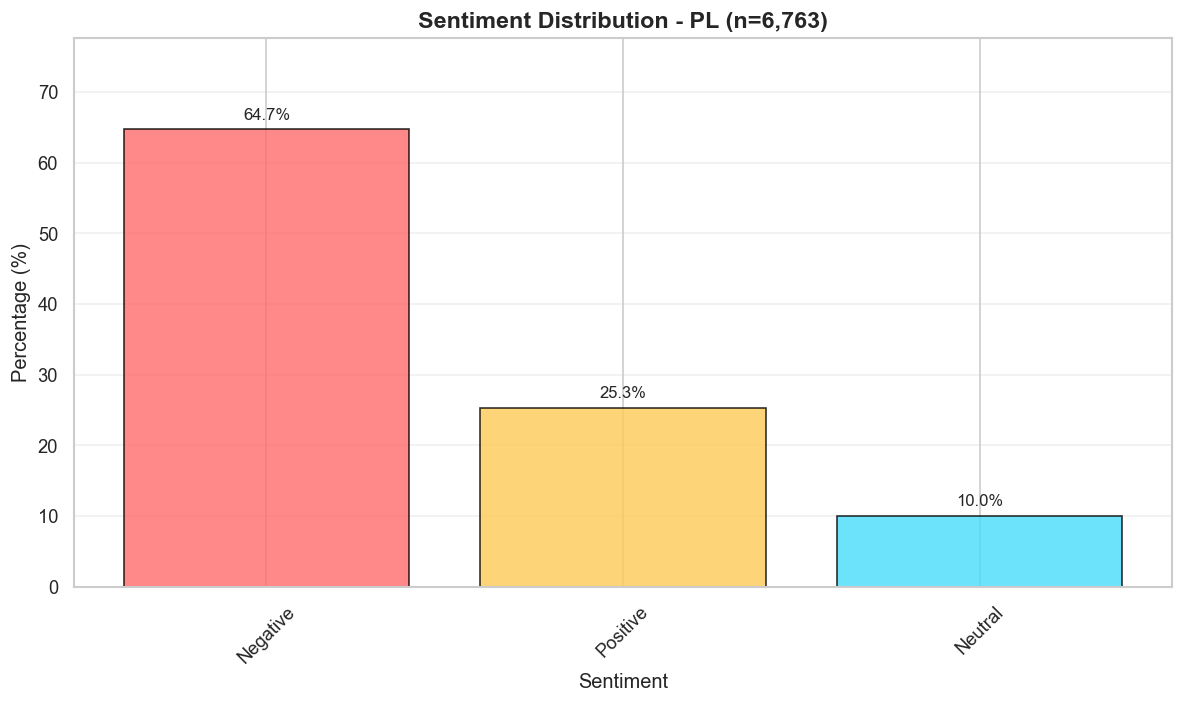

In [7]:
# CELL 6: Visualization
print('\nGenerating visualization...')
plot_sentiment_bar(df_pl, 'pl', 'sentiment')

In [8]:
# CELL 7: Export sentiment report
sentiment_report = pd.DataFrame({
    'sentiment': sentiment_counts.index,
    'count': sentiment_counts.values,
    'percentage': sentiment_pct.values
})
sentiment_report.to_csv(OUTPUT_DIR / 'polish' / 'pl_sentiment_report.csv', index=False)
print(f"✓ Saved: {OUTPUT_DIR / 'polish' / 'pl_sentiment_report.csv'}")

print('\n' + '='*70)
print('✓ BLOCK 4 COMPLETE - SENTIMENT ANALYSIS DONE')
print('='*70)


✓ Saved: outputs\polish\pl_sentiment_report.csv

✓ BLOCK 4 COMPLETE - SENTIMENT ANALYSIS DONE
